# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Rodiah Hasan Alaydrus
- **Email:** diahalaydrus1904@gmail.com
- **ID Dicoding:** diah1904

## Menentukan Pertanyaan Bisnis

- Berapa total pendapatan yang dihasilkan setiap bulan?
- Kategori produk apa yang menghasilkan pendapatan tertinggi?
- Provinsi mana yang memiliki jumlah pelanggan terbanyak?
- Apakah terdapat hubungan antara waktu pengiriman dan skor ulasan pelanggan?
- Berapa rata-rata waktu pengiriman, dan wilayah mana yang mengalami keterlambatan pengiriman paling sering?
- Penjual (seller) mana yang menghasilkan pendapatan tertinggi?
- Kategori produk mana yang memiliki skor ulasan rata-rata tertinggi dan terendah?

## Import Semua Packages/Library yang Digunakan

In [214]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import plotly.express as px
import seaborn as sns
import json

## Data Wrangling

### Gathering Data

In [215]:
# Memuat table customer
file_id = "1ECIc243045t5k9dEmxDlijOIIv1NKXBC"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

customer_df = pd.read_csv(url)
customer_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [216]:
# Memuat table geolocation
file_id = "1DRfQ49-LHBcuNBAkk0t41EhMm56cfVOM"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

geolocation_df = pd.read_csv(url)
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [217]:
# Memuat table order item
file_id = "1-GMq0M-WRGyqSg_nN7xVeN9z0cVSM_VI"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

order_item_df = pd.read_csv(url)
order_item_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [218]:
# Memuat table order payments
file_id = "1EEetUorU5UY6FNT1hz3MtcPklSi5o1c9"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

order_payments_df = pd.read_csv(url)
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [219]:
# Memuat table order review
file_id = "1w-_okLnbMARGBVfBren7FSIIHoTEXYZt"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

order_review_df = pd.read_csv(url)
order_review_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [220]:
# Memuat table order
file_id = "17vnFbRVDzDruQ33jreHcvVf56iSUiL1q"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

order_df = pd.read_csv(url)
order_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [221]:
# Memuat table terjemahaan product category
file_id = "180YJiMzesbk06Ung4qOKQI-vNrquKiFa"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

product_category_df = pd.read_csv(url)
product_category_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [222]:
# Memuat table products
file_id = "13BG_2eWYj3KIIXZIyBBjxZ-dK3bgRwhn"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

products_df = pd.read_csv(url)
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [223]:
# Memuat table seller
file_id = "1GrgfcEuiTaAPnvatXxJKecgyaC1dzT2p"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

seller_df = pd.read_csv(url)
seller_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


**Insight:**
- Table customer memiliki 5 kolumn yang membahas ID pelanggan, zip code pelanggan, kota pelanggan, dan provinsi pelanggan.
- xxx

### Assessing Data

Assesing Data (Customers)

In [224]:
# Memeriksa tipe data
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [225]:
# Memeriksa jumlah null values
customer_df.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [226]:
# Memeriksa jumlah duplikasi
print("Jumlah duplikasi: ", customer_df.duplicated().sum())

Jumlah duplikasi:  0


In [227]:
# Memeriksa parameter statistik dari kolom numerik
customer_df.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


Assesing Data Geolocation

In [228]:
# Memeriksa tipe data
geolocation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [229]:
# Memeriksa jumlah null values
geolocation_df.isna().sum()

,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0


In [230]:
# Memeriksa jumlah duplikasi
print("Jumlah duplikasi: ", geolocation_df.duplicated().sum())

Jumlah duplikasi:  261831


In [231]:
# Memeriksa parameter statistik dari kolom numerik
geolocation_df.describe()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


Assesing Data Order Item

In [232]:
# Memeriksa tipe data
order_item_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [233]:
# Memeriksa jumlah null values
order_item_df.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [234]:
# Memeriksa jumlah duplikasi
print("Jumlah duplikasi: ", order_item_df.duplicated().sum())

Jumlah duplikasi:  0


In [235]:
# Memeriksa parameter statistik dari kolom numerik
order_item_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


Assesing Data Order Payments

In [236]:
# Memeriksa tipe data
order_payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [237]:
# Memeriksa jumlah null values
order_payments_df.isna().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [238]:
# Memeriksa jumlah duplikasi
print("Jumlah duplikasi: ", order_payments_df.duplicated().sum())

Jumlah duplikasi:  0


In [239]:
# Memeriksa parameter statistik dari kolom numerik
order_payments_df.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


Assesing Data Order Reviews

In [240]:
# Memeriksa tipe data
order_review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [241]:
# Memeriksa jumlah null values
order_review_df.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [242]:
# Memeriksa jumlah duplikasi
print("Jumlah duplikasi: ", order_review_df.duplicated().sum())

Jumlah duplikasi:  0


In [243]:
# Memeriksa parameter statistik dari kolom numerik
order_review_df.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


Assesing Data Orders

In [244]:
# Memeriksa tipe data
order_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [245]:
# Memeriksa jumlah null values
order_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [246]:
# Memeriksa jumlah duplikasi
print("Jumlah duplikasi: ", order_df.duplicated().sum())

Jumlah duplikasi:  0


In [247]:
# Memeriksa parameter statistik dari kolom numerik
order_df.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


Assesing Data Product Category

In [248]:
# Memeriksa tipe data
product_category_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [249]:
# Memeriksa jumlah null values
product_category_df.isna().sum()

,0
product_category_name,0
product_category_name_english,0


In [250]:
# Memeriksa jumlah duplikasi
print("Jumlah duplikasi: ", product_category_df.duplicated().sum())

Jumlah duplikasi:  0


In [251]:
# Memeriksa parameter statistik dari kolom numerik
product_category_df.describe()

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


Assesing Data Products

In [252]:
# Memeriksa tipe data
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [253]:
# Memeriksa jumlah null values
products_df.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [254]:
# Memeriksa jumlah duplikasi
print("Jumlah duplikasi: ", products_df.duplicated().sum())

Jumlah duplikasi:  0


In [255]:
# Memeriksa parameter statistik dari kolom numerik
products_df.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


Assesing Data Sellers

In [256]:
# Memeriksa tipe data
seller_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [257]:
# Memeriksa jumlah null values
seller_df.isna().sum()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


In [258]:
# Memeriksa jumlah duplikasi
print("Jumlah duplikasi: ", seller_df.duplicated().sum())

Jumlah duplikasi:  0


In [259]:
# Memeriksa parameter statistik dari kolom numerik
seller_df.describe()

,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


**Insight:**
- Terdapat data duplikat pada tabel geolocation.
- Kolom shipping_limit_date pada tabel order_items seharusnya menggunakan tipe data datetime.
- Kolom review_comment_title dan review_comment_message pada tabel order_reviews mengandung nilai null.
- Kolom order_approved_at, order_delivered_carrier_date, dan order_delivered_customer_date pada tabel orders memiliki nilai null.
- Beberapa kolom pada tabel orders perlu dikonversi ke tipe data datetime.
- Tabel products memiliki beberapa kolom yang mengandung nilai null.

### Cleaning Data

Data duplikasi di tabel geolocation

In [260]:
# Menghapus data duplicat dari table geolocation
geolocation_df.drop_duplicates(inplace=True)

print("Jumlah duplikasi: ", geolocation_df.duplicated().sum())

Jumlah duplikasi:  0


Format tipe data di tabel order item

In [261]:
# Mengubah datatype kolumn di table order item menjadi datetime
datetime_columns = ["shipping_limit_date"]

for column in datetime_columns:
  order_item_df[column] = pd.to_datetime(order_item_df[column])

order_item_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


Nilai null di tabel order review

In [262]:
# Melihat baris dengan nilai null
order_review_df[order_review_df.review_comment_title.isna()]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [263]:
# Melihat isi terbanyak untuk kolom review_comment_title
order_review_df.review_comment_title.value_counts()

,count
review_comment_title,
Recomendo,423
recomendo,345
Bom,293
super recomendo,270
Excelente,248
...,...
medidas do produto,1
"Muito, entregou antes do",1
Tudo dentro do combinado.,1


In [264]:
# Mengisi nilai null dalam kolom review comment title dengan isi yang terbanyak
order_review_df.fillna(
    {"review_comment_title": "Recomendo"},
    inplace=True
)

order_review_df.review_comment_title.isna().sum()

np.int64(0)

In [265]:
# Melihat baris dengan nilai null
order_review_df[order_review_df.review_comment_message.isna()]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,Recomendo,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,Recomendo,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,Recomendo,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,Recomendo,NaN,2018-04-13 00:00:00,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,Recomendo,NaN,2017-07-16 00:00:00,2017-07-18 19:30:34
...,...,...,...,...,...,...,...
99217,c6b270c61f67c9f7cb07d84ea8aeaf8b,48f7ee67313eda32bfcf5b9c1dd9522d,5,Recomendo,NaN,2017-12-13 00:00:00,2017-12-14 11:09:36
99218,af2dc0519de6e0720ef0c74292fb4114,d699c734a0b1c8111f2272a3f36d398c,5,Recomendo,NaN,2018-04-27 00:00:00,2018-04-30 01:18:57
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,Recomendo,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,Recomendo,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42


In [266]:
# Melihat isi yang terbanyak di kolom review_comment_message
order_review_df.review_comment_message.value_counts()

,count
review_comment_message,
Muito bom,230
Bom,189
muito bom,122
bom,107
Recomendo,100
...,...
qualidade.,1
chegou bem antes do prazo previsto,1
Ja respondi esse questionario.,1


In [267]:
# Mengisi null values dalam kolumn review comment message dengan nilai yang dominan
order_review_df.fillna(
    {"review_comment_message": "Muito bom"},
    inplace=True
)

order_review_df.review_comment_message.isna().sum()

np.int64(0)

Nilai null di tabel orders

In [268]:
# Melihat baris dengan nilai null
order_df[order_df.order_approved_at.isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaN,NaN,NaN,2018-09-12 00:00:00
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaN,NaN,NaN,2018-10-17 00:00:00
1868,df8282afe61008dc26c6c31011474d02,aa797b187b5466bc6925aaaa4bb3bed1,canceled,2017-03-04 12:14:30,NaN,NaN,NaN,2017-04-10 00:00:00
2029,8d4c637f1accf7a88a4555f02741e606,b1dd715db389a2077f43174e7a675d07,canceled,2018-08-29 16:27:49,NaN,NaN,NaN,2018-09-13 00:00:00
2161,7a9d4c7f9b068337875b95465330f2fc,7f71ae48074c0cfec9195f88fcbfac55,canceled,2017-05-01 16:12:39,NaN,NaN,NaN,2017-05-30 00:00:00
...,...,...,...,...,...,...,...,...
97696,5a00b4d35edffc56b825c3646a99ba9d,6a3bdf004ca96338fb5fad1b8d93c2e6,canceled,2017-07-02 15:38:46,NaN,NaN,NaN,2017-07-25 00:00:00
98415,227c804e2a44760671a6a5697ea549e4,62e7477e75e542243ee62a0ba73f410f,canceled,2017-09-28 15:02:56,NaN,NaN,NaN,2017-10-16 00:00:00
98909,e49e7ce1471b4693482d40c2bd3ad196,e4e7ab3f449aeb401f0216f86c2104db,canceled,2018-08-07 11:16:28,NaN,NaN,NaN,2018-08-10 00:00:00
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00


In [269]:
# Menghapus baris dengan nilai null
order_df = order_df.dropna(subset=['order_approved_at'])

order_df.order_approved_at.isna().sum()

np.int64(0)

In [270]:
# Melihat baris dengan nilai null
order_df[order_df.order_delivered_carrier_date.isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaN,NaN,2018-08-21 00:00:00
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaN,NaN,2017-10-03 00:00:00
266,8e24261a7e58791d10cb1bf9da94df5c,64a254d30eed42cd0e6c36dddb88adf0,unavailable,2017-11-16 15:09:28,2017-11-16 15:26:57,NaN,NaN,2017-12-05 00:00:00
324,d3c8851a6651eeff2f73b0e011ac45d0,957f8e082185574de25992dc659ebbc0,processing,2016-10-05 22:44:13,2016-10-06 15:51:05,NaN,NaN,2016-12-09 00:00:00
...,...,...,...,...,...,...,...,...
99233,1c7c8ab324927f5b6e52338bd110bef4,95b1767df51d6fa09402267d8de314df,unavailable,2017-12-23 18:48:09,2017-12-23 18:54:22,NaN,NaN,2018-01-19 00:00:00
99252,aaab15da689073f8f9aa978a390a69d1,df20748206e4b865b2f14a5eabbfcf34,unavailable,2018-01-16 14:27:59,2018-01-17 03:37:34,NaN,NaN,2018-02-06 00:00:00
99313,e9e64a17afa9653aacf2616d94c005b8,b4cd0522e632e481f8eaf766a2646e86,processing,2018-01-05 23:07:24,2018-01-09 07:18:05,NaN,NaN,2018-02-06 00:00:00
99348,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,2017-08-23 16:28:04,2017-08-28 15:44:47,NaN,NaN,2017-09-15 00:00:00


In [271]:
# Menghapus baris dengan nilai null
order_df = order_df.dropna(subset=['order_delivered_carrier_date'])

order_df.order_delivered_carrier_date.isna().sum()

np.int64(0)

In [272]:
# Melihat baris dengan nilai null
order_df[order_df.order_delivered_customer_date.isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaN,2018-06-28 00:00:00
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaN,2018-02-07 00:00:00
162,36530871a5e80138db53bcfd8a104d90,4dafe3c841d2d6cc8a8b6d25b35704b9,shipped,2017-05-09 11:48:37,2017-05-11 11:45:14,2017-05-11 13:21:47,NaN,2017-06-08 00:00:00
231,4d630f57194f5aba1a3d12ce23e71cd9,6d491c9fe2f04f6e2af6ec033cd8907c,shipped,2017-11-17 19:53:21,2017-11-18 19:50:31,2017-11-22 17:28:34,NaN,2017-12-13 00:00:00
299,3b4ad687e7e5190db827e1ae5a8989dd,1a87b8517b7d31373b50396eb15cb445,shipped,2018-06-28 12:52:15,2018-06-28 13:11:09,2018-07-04 15:20:00,NaN,2018-08-03 00:00:00
...,...,...,...,...,...,...,...,...
98534,a59ef0abffbef8ddaae23600b6ee6604,49e64271fb8eeb19851dc7e850e92204,shipped,2017-11-06 17:35:49,2017-11-07 06:31:44,2017-11-07 18:57:39,NaN,2017-11-24 00:00:00
98779,dab8a6c6bd6ec448df5b3a6b6cb887bc,394653a10cab83cad40d7e2713f3ab89,shipped,2018-07-14 10:12:51,2018-07-16 12:30:58,2018-07-16 14:34:00,NaN,2018-08-03 00:00:00
98932,492aed3c33bac22a8e04138319829283,58466c1166c377a56f6b2ae0d93ffbc0,shipped,2018-07-06 16:26:47,2018-07-06 16:35:10,2018-07-10 12:27:00,NaN,2018-07-26 00:00:00
99113,274a7f7e4f1c17b7434a830e9b8759b1,670af30ca5b8c20878fecdafa5ee01b9,shipped,2018-06-23 13:25:15,2018-06-23 13:40:11,2018-07-04 13:51:00,NaN,2018-07-24 00:00:00


In [273]:
# Menghapus baris dengan nilai null
order_df = order_df.dropna(subset=['order_delivered_customer_date'])

order_df.order_delivered_customer_date.isna().sum()

np.int64(0)

Format tipe data yang salah di tabel orders

In [274]:
# Mengubah datatype kolumn di table order menjadi datetime
datetime_columns = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date"]

for column in datetime_columns:
  order_df[column] = pd.to_datetime(order_df[column])

order_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96461 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96461 non-null  object        
 1   customer_id                    96461 non-null  object        
 2   order_status                   96461 non-null  object        
 3   order_purchase_timestamp       96461 non-null  datetime64[ns]
 4   order_approved_at              96461 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96461 non-null  datetime64[ns]
 6   order_delivered_customer_date  96461 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96461 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.6+ MB


Nilai null di tabel products

In [275]:
# Menghapus baris dengan nilai null
products_df = products_df.dropna()

products_df.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


**Insight:**
- Data duplikat pada tabel geolocation diidentifikasi dan dihapus.
- Tipe data kolom shipping_limit_date pada tabel order_items diubah menjadi datetime.
- Nilai null pada kolom review_comment_title dan review_comment_message di tabel order_reviews ditangani.
- Nilai null pada kolom order_approved_at, order_delivered_carrier_date, dan order_delivered_customer_date di tabel orders ditangani.
- Beberapa kolom tanggal pada tabel orders dikonversi ke tipe data datetime.
- Nilai null pada beberapa kolom di tabel products ditangani.

## Exploratory Data Analysis (EDA)

In [276]:
# Menampilkan 5 data paling atas dari dataframe order item
order_item_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [277]:
# Melakukan statistik deskriptif dan ringkasan seluruh kolom pada dataset order_item
order_item_df.describe(include="all")

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,NaN,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,NaN,NaN,NaN
freq,21,NaN,527,2033,NaN,NaN,NaN
mean,NaN,1.197834,NaN,NaN,2018-01-07 15:36:52.192685312,120.653739,19.990320
min,NaN,1.000000,NaN,NaN,2016-09-19 00:15:34,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,2017-09-20 20:57:27.500000,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,2018-01-26 13:59:35,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,2018-05-10 14:34:00.750000128,134.900000,21.150000
max,NaN,21.000000,NaN,NaN,2020-04-09 22:35:08,6735.000000,409.680000


In [278]:
# Analisis per produk: jumlah order unik serta statistik biaya pengiriman (maksimum, minimum, rata-rata, dan standar deviasi)
order_item_df.groupby(by="product_id").agg({
    "order_id": "nunique",
    "freight_value": ["max", "min", "mean", "std"]
})

order_id freight_value                 \
                                  nunique           max    min    mean   
product_id                                                               
00066f42aeeb9f3007548bb9d3f33c38        1         18.59  18.59  18.590   
00088930e925c41fd95ebfe695fd2655        1         13.93  13.93  13.930   
0009406fd7479715e4bef61dd91f2462        1         13.10  13.10  13.100   
000b8f95fcb9e0096488278317764d19        2         19.60  19.60  19.600   
000d9be29b5207b54e86aa1b1ac54872        1         19.27  19.27  19.270   
...                                   ...           ...    ...     ...   
fff6177642830a9a94a0f2cba5e476d1        2         38.39  17.02  27.705   
fff81cc3158d2725c0655ab9ba0f712c        1          7.89   7.89   7.890   
fff9553ac224cec9d15d49f5a263411f        1         11.85  11.85  11.850   
fffdb2d0ec8d6a61f0a0a0db3f25b441        5         18.23   7.39  11.774   
fffe9eeff12fcbd74a2f2b007dde0c58        1         53.88  53.88  53.880   

                                             
                                        std  
product_id                                   
00066f42aeeb9f3007548bb9d3f33c38        NaN  
00088930e925c41fd95ebfe695fd2655        NaN  
0009406fd7479715e4bef61dd91f2462        NaN  
000b8f95fcb9e0096488278317764d19   0.000000  
000d9be29b5207b54e86aa1b1ac54872        NaN  
...                                     ...  
fff6177642830a9a94a0f2cba5e476d1  15.110872  
fff81cc3158d2725c0655ab9ba0f712c        NaN  
fff9553ac224cec9d15d49f5a263411f        NaN  
fffdb2d0ec8d6a61f0a0a0db3f25b441   5.893698  
fffe9eeff12fcbd74a2f2b007dde0c58        NaN  

[32951 rows x 5 columns]

In [279]:
# Number of unique customers per city
customer_df.groupby("customer_city")["customer_id"] \
           .nunique() \
           .sort_values(ascending=False)

# Number of unique customers per state
customer_df.groupby("customer_state")["customer_id"] \
           .nunique() \
           .sort_values(ascending=False)

,customer_id
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


**Insight:**
- Sebagian besar produk hanya muncul satu kali per pesanan, dan banyak produk memiliki jumlah pesanan yang sangat rendah, menunjukkan pola permintaan long-tail.
- Biaya pengiriman bervariasi cukup besar antar produk, di mana beberapa produk memiliki variasi biaya yang tinggi sementara produk lain cenderung stabil.
- Pelanggan terkonsentrasi secara geografis, dengan provinsi São Paulo (SP) memiliki jumlah pelanggan unik paling tinggi dibandingkan provinsi lainnya.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Berapa total pendapatan yang dihasilkan setiap bulan?

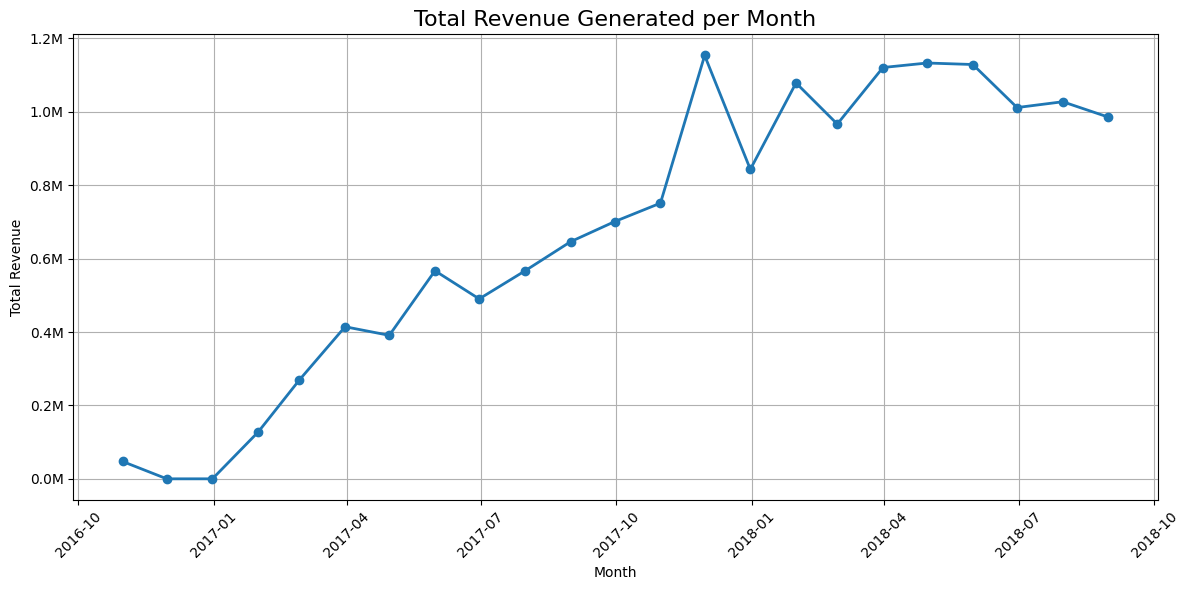

In [280]:
# Menggabungkan data order dan pembayaran lalu menghitung total revenue bulanan.

all_df = order_df.merge(
    order_payments_df,
    on="order_id",
    how="inner"
)

monthly_revenue_df = all_df.resample(
    rule="ME",
    on="order_purchase_timestamp"
).agg({
    "payment_value": "sum"
})

monthly_revenue_df = monthly_revenue_df.reset_index()
monthly_revenue_df.rename(columns={
    "order_purchase_timestamp": "month",
    "payment_value": "total_revenue"
}, inplace=True)

 # Membuat visualisasi

plt.figure(figsize=(12, 6))
plt.plot(
    monthly_revenue_df["month"],
    monthly_revenue_df["total_revenue"],
    marker='o',
    linewidth=2
)

formatter = FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Total Revenue Generated per Month", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Pertanyaan 2: Kategori produk apa yang menghasilkan pendapatan tertinggi?

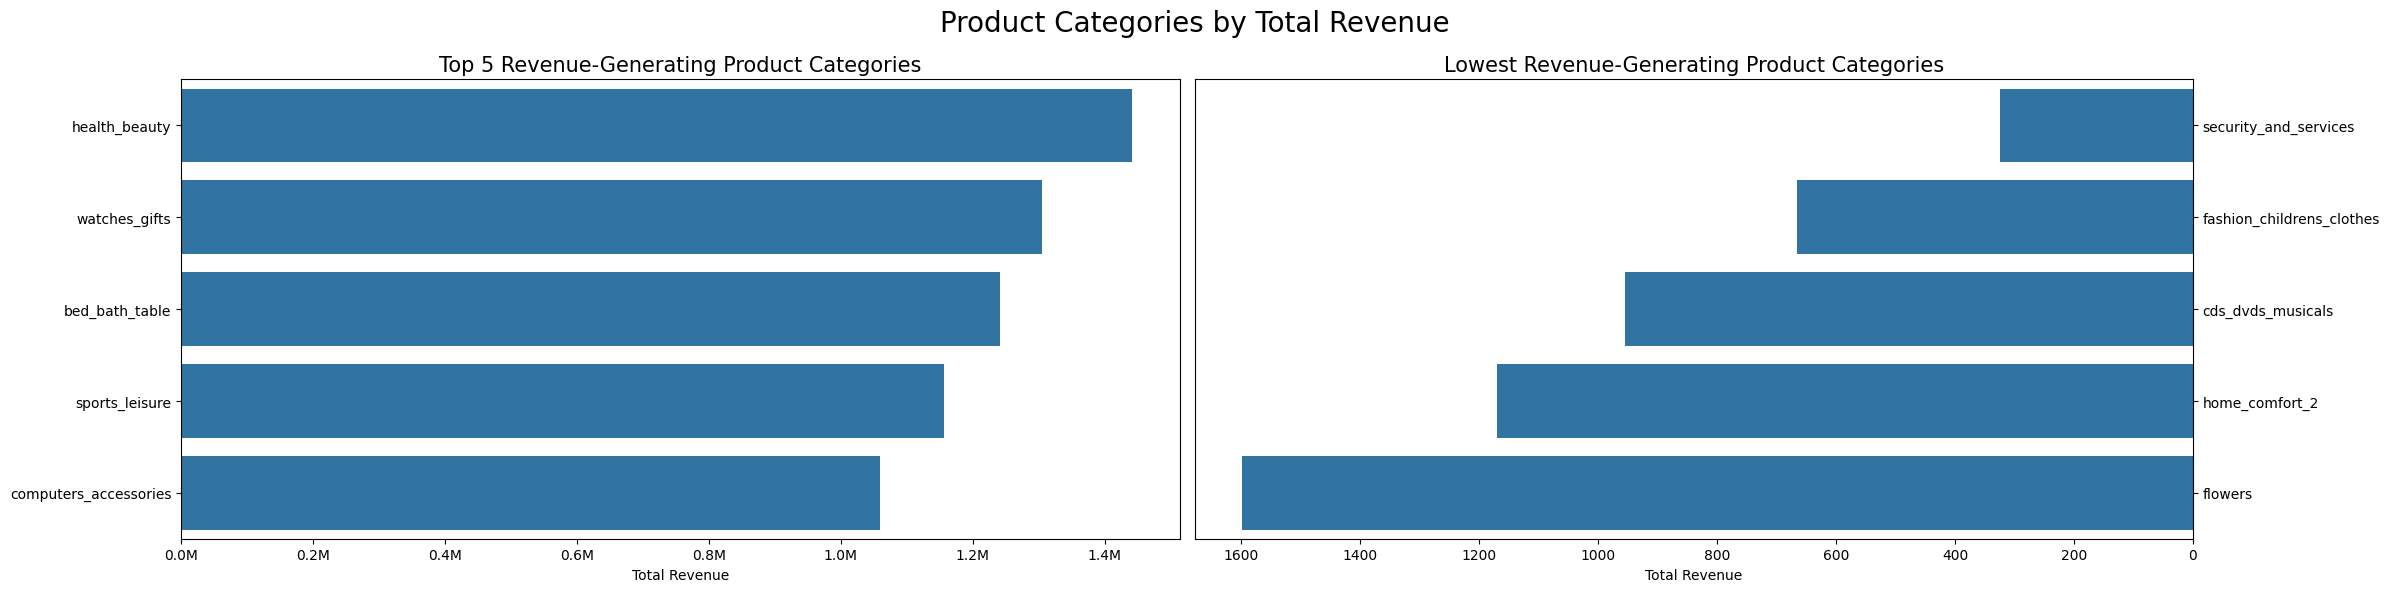

In [281]:
# Menggabungkan data produk dan kategori lalu menghitung total revenue per kategori produk.

merged_df = order_item_df.merge(
    products_df,
    on="product_id",
    how="left"
)

merged_df = merged_df.merge(
    product_category_df,
    on="product_category_name",
    how="left"
)

merged_df["revenue"] = merged_df["price"] + merged_df["freight_value"]

category_revenue_df = (
    merged_df
    .groupby("product_category_name_english", as_index=False)
    .agg(total_revenue=("revenue", "sum"))
    .sort_values(by="total_revenue", ascending=False)
)

million_formatter = FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M')
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

# 5 kategori tertinggi berdasarkan pendapatan
sns.barplot(
    x="total_revenue",
    y="product_category_name_english",
    data=category_revenue_df.head(5),
    ax=ax[0]
)
ax[0].set_title("Top 5 Revenue-Generating Product Categories", fontsize=15)
ax[0].set_xlabel("Total Revenue")
ax[0].set_ylabel(None)
ax[0].xaxis.set_major_formatter(million_formatter)

# 5 kategori terendah berdasarkan pendapatan
sns.barplot(
    x="total_revenue",
    y="product_category_name_english",
    data=category_revenue_df.sort_values("total_revenue").head(5),
    ax=ax[1]
)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Lowest Revenue-Generating Product Categories", fontsize=15)
ax[1].set_xlabel("Total Revenue")
ax[1].set_ylabel(None)

plt.suptitle(
    "Product Categories by Total Revenue",
    fontsize=20
)
plt.tight_layout()
plt.show()

### Pertanyaan 3: Provinsi mana yang memiliki jumlah pelanggan terbanyak?

In [282]:
# Menggabungkan data order dan pelanggan lalu menghitung jumlah pelanggan dan order per state.

geo_df = order_df.merge(
    customer_df,
    on="customer_id",
    how="left"
)

customers_by_state = (
    geo_df.groupby("customer_state")
          .agg(total_customers=("customer_unique_id", "nunique"))
          .reset_index()
)

orders_by_state = (
    geo_df.groupby("customer_state")
          .agg(total_orders=("order_id", "nunique"))
          .reset_index()
)

fig = px.choropleth(
    customers_by_state,
    locations="customer_state",
    locationmode="geojson-id",
    geojson="https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson",
    featureidkey="properties.sigla",
    color="total_customers",
    color_continuous_scale="Blues",
    title="Number of Customers by State in Brazil"
)

fig.update_geos(
    fitbounds="locations",
    visible=False
)

fig.show()

### Pertanyaan 4: Apakah terdapat hubungan antara waktu pengiriman dan skor ulasan pelanggan?

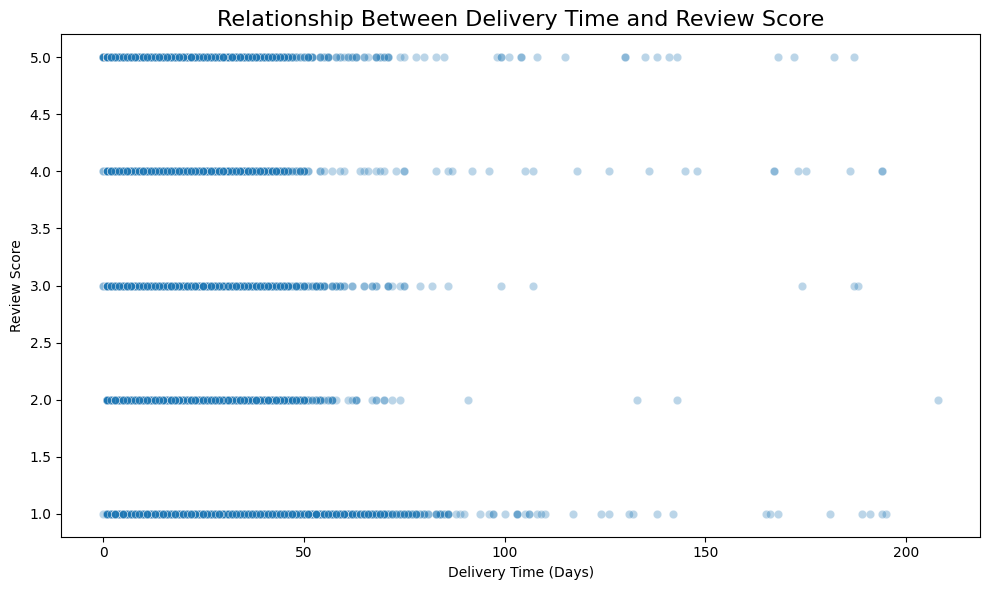

In [283]:
# Menggabungkan data order dan review lalu menghitung delivery time dan menghapus nilai tidak valid.

df = order_df.merge(
    order_review_df,
    on="order_id",
    how="inner"
)

df["delivery_time_days"] = (
    df["order_delivered_customer_date"] -
    df["order_purchase_timestamp"]
).dt.days

df = df[df["delivery_time_days"] >= 0]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="delivery_time_days",
    y="review_score",
    alpha=0.3
)

plt.title("Relationship Between Delivery Time and Review Score", fontsize=16)
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Review Score")
plt.tight_layout()
plt.show()

### Pertanyaan 5: Berapa rata-rata waktu pengiriman, dan wilayah mana yang mengalami keterlambatan pengiriman paling sering?

In [284]:
# Menggabungkan data order dan pelanggan lalu menghitung rata-rata waktu pengiriman serta delivery time per state.

delivery_df = order_df.merge(
    customer_df,
    on="customer_id",
    how="left"
)

delivery_df["delivery_time_days"] = (
    delivery_df["order_delivered_customer_date"] -
    delivery_df["order_purchase_timestamp"]
).dt.days

delivery_df = delivery_df[delivery_df["delivery_time_days"] >= 0]

average_delivery_time = delivery_df["delivery_time_days"].mean()
delivery_by_state = (
    delivery_df.groupby("customer_state", as_index=False)
               .agg(
                   avg_delivery_time=("delivery_time_days", "mean"),
                   total_orders=("order_id", "nunique")
               )
               .sort_values("avg_delivery_time", ascending=False)
)

fig = px.choropleth(
    delivery_by_state,
    locations="customer_state",
    geojson="https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson",
    featureidkey="properties.sigla",
    color="avg_delivery_time",
    color_continuous_scale="Blues",
    title="Average Delivery Time by State (Days)"
)

fig.update_geos(fitbounds="locations", visible=False)
fig.show()

### Pertanyaan 6: Penjual (seller) mana yang menghasilkan pendapatan tertinggi?

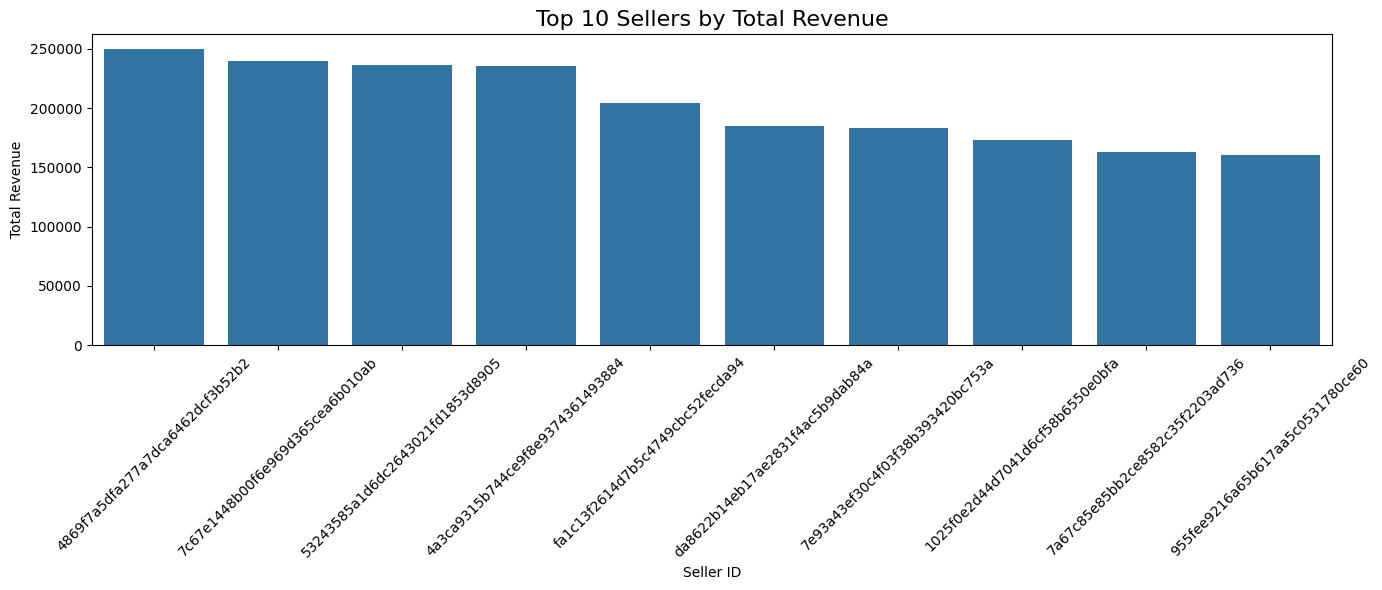

In [285]:
# Menghitung revenue per item lalu menentukan 10 seller dengan total revenue tertinggi.

order_item_df["revenue"] = (
    order_item_df["price"] + order_item_df["freight_value"]
)

seller_revenue_df = (
    order_item_df
    .groupby("seller_id", as_index=False)
    .agg(total_revenue=("revenue", "sum"))
    .sort_values("total_revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(14, 6))

sns.barplot(
    data=seller_revenue_df,
    x="seller_id",
    y="total_revenue"
)

plt.title("Top 10 Sellers by Total Revenue", fontsize=16)
plt.xlabel("Seller ID")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Pertanyaan 7: Kategori produk mana yang memiliki skor ulasan rata-rata tertinggi dan terendah?

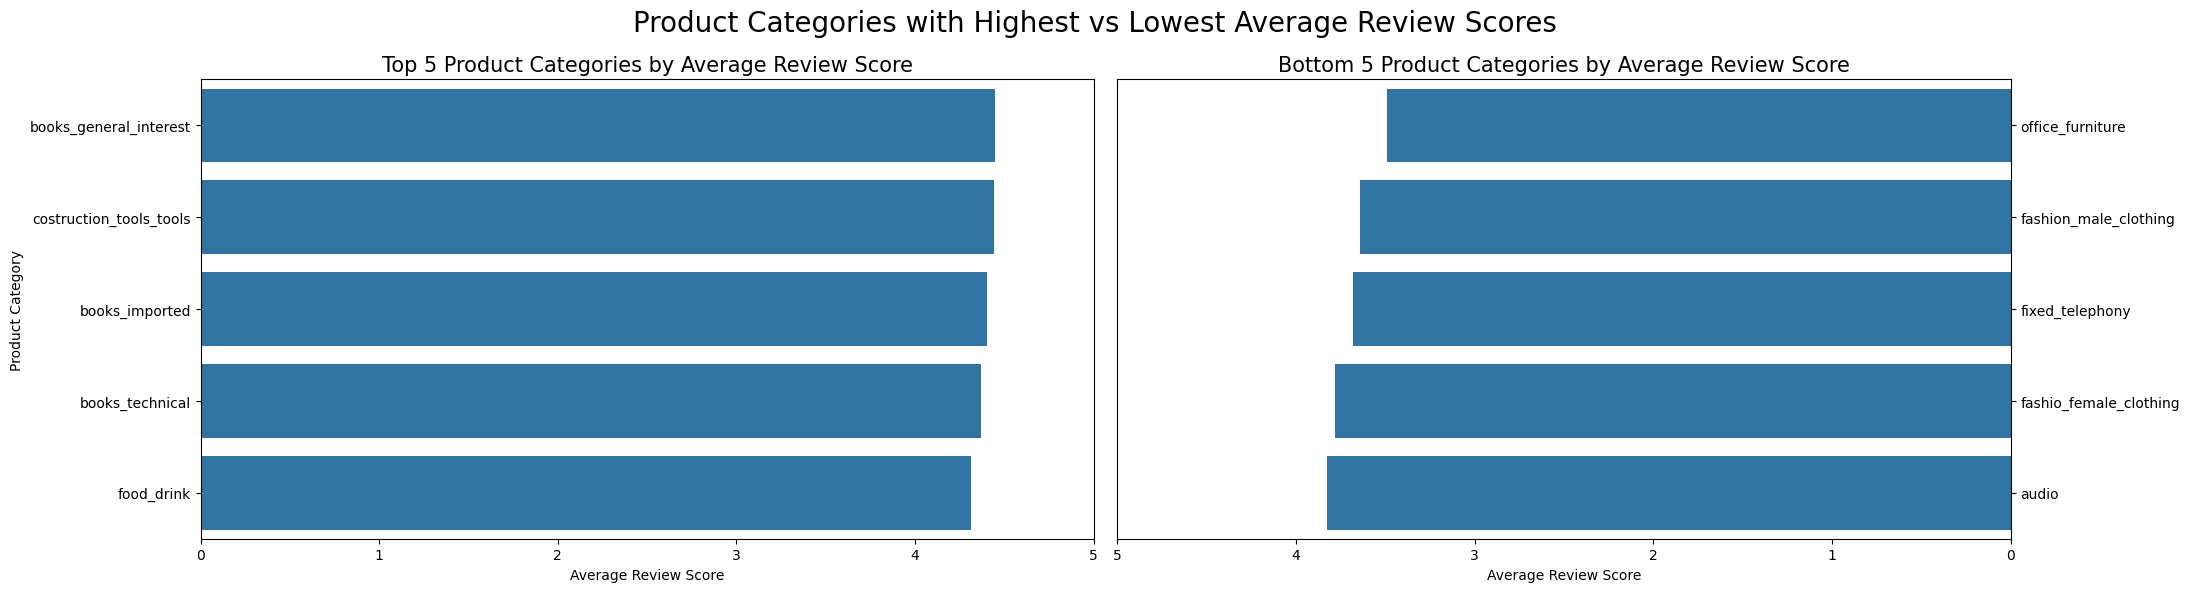

In [286]:
# Menggabungkan data item, review, dan produk lalu menghitung rata-rata skor review per kategori produk.

review_category_df = order_item_df.merge(
    order_review_df,
    on="order_id",
    how="inner"
)

review_category_df = review_category_df.merge(
    products_df,
    on="product_id",
    how="left"
)

review_category_df = review_category_df.merge(
    product_category_df,
    on="product_category_name",
    how="left"
)

category_review_df = (
    review_category_df.groupby("product_category_name_english")
                      .agg(
                          avg_review_score=("review_score", "mean"),
                          total_reviews=("review_score", "count")
                      )
                      .reset_index()
)

category_review_df = category_review_df[
    category_review_df["total_reviews"] >= 50
]

top_categories = (
    category_review_df
    .sort_values("avg_review_score", ascending=False)
    .head(5)
)

bottom_categories = (
    category_review_df
    .sort_values("avg_review_score", ascending=True)
    .head(5)
)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(22, 6))

# Rata-rata skor review tertinggi
sns.barplot(
    data=top_categories,
    x="avg_review_score",
    y="product_category_name_english",
    ax=ax[0]
)

ax[0].set_title("Top 5 Product Categories by Average Review Score", fontsize=15)
ax[0].set_xlabel("Average Review Score")
ax[0].set_ylabel("Product Category")
ax[0].set_xlim(0, 5)

# Rata-rata skor review terendah
sns.barplot(
    data=bottom_categories,
    x="avg_review_score",
    y="product_category_name_english",
    ax=ax[1]
)

ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()

ax[1].set_title("Bottom 5 Product Categories by Average Review Score", fontsize=15)
ax[1].set_xlabel("Average Review Score")
ax[1].set_ylabel(None)
ax[1].set_xlim(5, 0)

plt.suptitle(
    "Product Categories with Highest vs Lowest Average Review Scores",
    fontsize=20
)
plt.tight_layout()
plt.show()

**Insight:**
- Pendapatan bulanan menunjukkan tren meningkat dari waktu ke waktu, dengan puncak pendapatan terjadi pada akhir 2017 hingga pertengahan 2018.
- Kategori health_beauty menjadi penyumbang pendapatan tertinggi, sementara beberapa kategori seperti security_and_services berkontribusi sangat kecil terhadap total pendapatan.
- Provinsi São Paulo (SP) memiliki jumlah pelanggan paling banyak, jauh melampaui provinsi lain di Brasil.
- Terdapat kecenderungan hubungan negatif antara waktu pengiriman dan skor ulasan, di mana pengiriman yang lebih lama sering dikaitkan dengan skor ulasan yang lebih rendah.
- Rata-rata waktu pengiriman berbeda antar provinsi, dengan wilayah bagian utara dan barat Brasil cenderung mengalami waktu pengiriman yang lebih lama.
- Pendapatan seller terdistribusi tidak merata, di mana hanya sebagian kecil seller yang menghasilkan pendapatan sangat tinggi dibandingkan seller lainnya.
- Kategori produk berbasis buku dan makanan memiliki skor ulasan rata-rata tertinggi, sementara kategori seperti office_furniture dan fashion tertentu memiliki skor ulasan terendah.

## Analisis Lanjutan (Opsional)

### RFM

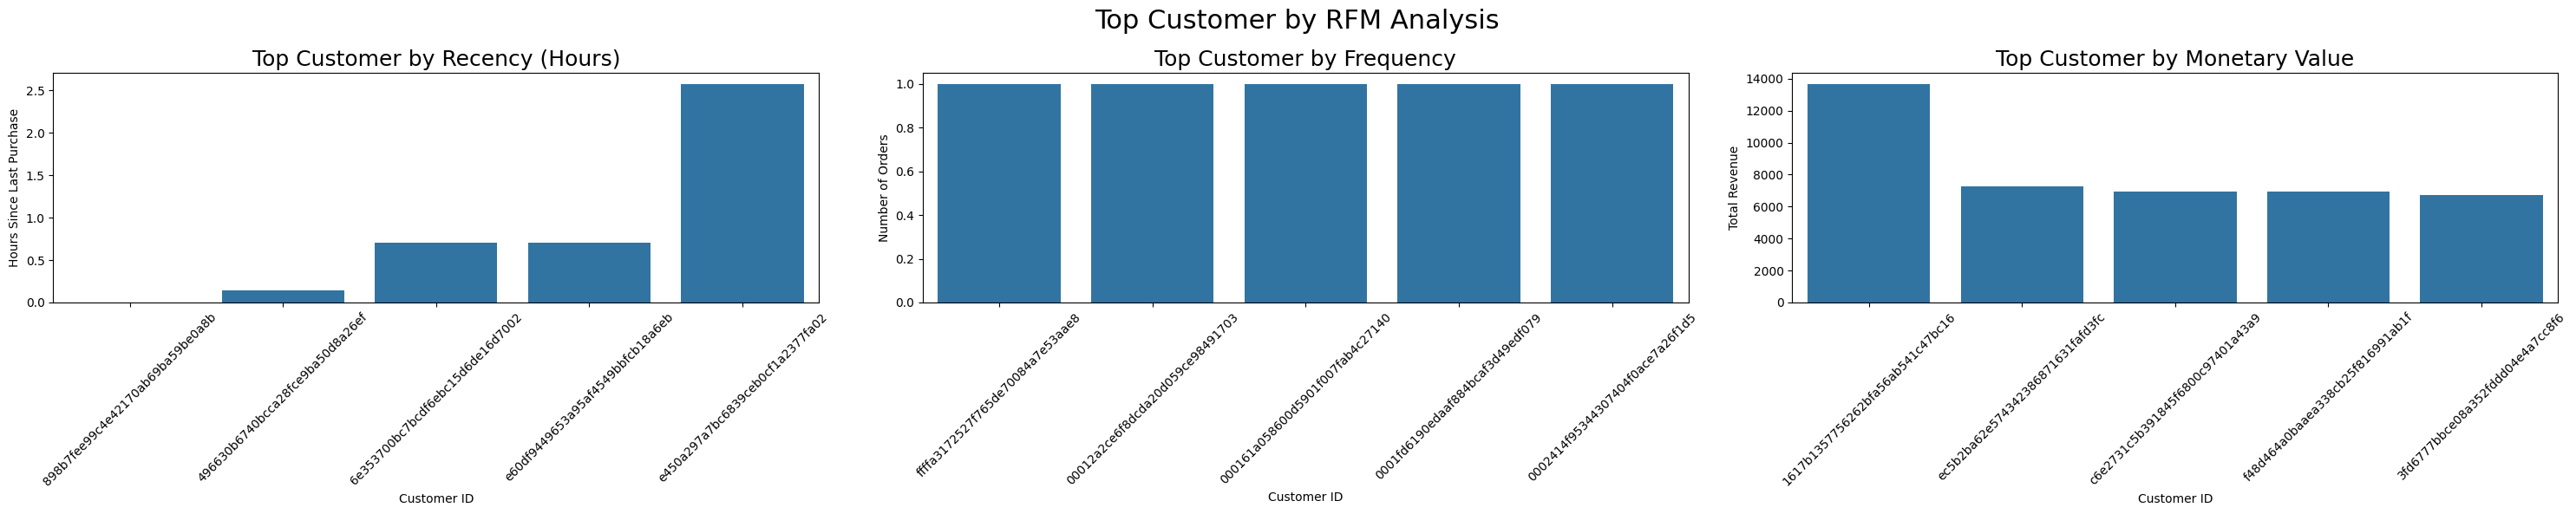

In [287]:
# Menggabungkan tabel orders + order items
all_df = order_df.merge(
    order_item_df,
    on="order_id",
    how="inner"
)

# Mengonversi timestamp menjadi datetime
all_df["order_purchase_timestamp"] = pd.to_datetime(
    all_df["order_purchase_timestamp"]
)

# Menghitung revenue per item
all_df["total_price"] = (
    all_df["price"] + all_df["freight_value"]
)

# Agregasi RFM
rfm_df = all_df.groupby("customer_id", as_index=False).agg({
    "order_purchase_timestamp": "max",
    "order_id": "nunique",
    "total_price": "sum"
})

rfm_df.columns = [
    "customer_id",
    "last_order_timestamp",
    "frequency",
    "monetary"
]


# Recency dalam jam
rfm_df["last_order_timestamp"] = pd.to_datetime(
    rfm_df["last_order_timestamp"]
)

# Datetime referensi
recent_datetime = all_df["order_purchase_timestamp"].max()

# Menghitung recency dalam satuan jam
rfm_df["recency_hours"] = (
    (recent_datetime - rfm_df["last_order_timestamp"])
    .dt.total_seconds() / 3600
)

# Menghapus kolom bantu
rfm_df.drop("last_order_timestamp", axis=1, inplace=True)

rfm_df.head()

# Visualisasi (RFM)
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 6))

# Recency
sns.barplot(
    data=rfm_df.sort_values("recency_hours").head(5),
    x="customer_id",
    y="recency_hours",
    ax=ax[0]
)

ax[0].set_ylim(bottom=0)
ax[0].set_title("Top Customer by Recency (Hours)", fontsize=18)
ax[0].set_xlabel("Customer ID")
ax[0].set_ylabel("Hours Since Last Purchase")
ax[0].tick_params(axis='x', rotation=45)

# Frequency
sns.barplot(
    data=rfm_df.sort_values("frequency", ascending=False).head(5),
    x="customer_id",
    y="frequency",
    ax=ax[1]
)

ax[1].set_title("Top Customer by Frequency", fontsize=18)
ax[1].set_xlabel("Customer ID")
ax[1].set_ylabel("Number of Orders")
ax[1].tick_params(axis='x', rotation=45)

# Monetary
sns.barplot(
    data=rfm_df.sort_values("monetary", ascending=False).head(5),
    x="customer_id",
    y="monetary",
    ax=ax[2]
)

ax[2].set_title("Top Customer by Monetary Value", fontsize=18)
ax[2].set_xlabel("Customer ID")
ax[2].set_ylabel("Total Revenue")
ax[2].tick_params(axis='x', rotation=45)

plt.suptitle(
    "Top Customer by RFM Analysis",
    fontsize=22
)
plt.tight_layout()
plt.show()

## Conclusion

- Total pendapatan bulanan bervariasi dan cenderung meningkat, dari hampir nol di awal periode hingga sekitar 1–1,15 juta pada puncaknya.
- Kategori dengan pendapatan tertinggi adalah health_beauty, sedangkan yang terendah adalah security_and_services.
- Provinsi dengan jumlah pelanggan terbanyak adalah São Paulo.
- Waktu pengiriman yang lebih lama cenderung berkorelasi dengan skor ulasan pelanggan yang lebih rendah.
- Rata-rata waktu pengiriman berada di kisaran 15–20 hari, dengan keterlambatan paling sering terjadi di wilayah Brasil Utara, khususnya provinsi seperti Amazonas dan sekitarnya.
- Penjual dengan pendapatan tertinggi adalah 4869f7a3dfa277a1dc46462dcf3b52b2.
- Kategori dengan skor ulasan rata-rata tertinggi adalah books_general_interest, sedangkan skor terendah terdapat pada kategori office_furniture.